# Lifetime PD — the evidence

Every statistic below is a tested function in `creditsurv`. This notebook calls them
and shows what came back; it contains no statistics of its own. Read
[`docs/variable_selection.md`](../docs/variable_selection.md) for the procedure and
the thresholds, and [`docs/data_dictionary.md`](../docs/data_dictionary.md) for what
the fields mean.

The **fit itself is not here**. On the whole population it is tens of minutes, so it
is a CLI step — `creditsurv fit` and `creditsurv report` — and this notebook reads
what they leave behind. That is the same division as
[`01_portfolio.ipynb`](01_portfolio.ipynb): the package computes, the commands
persist, the notebook shows.

In [ ]:
import warnings
from pathlib import Path

import pandas as pd
from IPython.display import Image

from creditsurv.config import reports_dir
from creditsurv.data.fred import load_macro_panel
from creditsurv.data.panel import WEIGHT, cells_to_episodes
from creditsurv.data.store import load_cells
from creditsurv.explore import curves_cross, default_rate_by_band, survival_by_stratum
from creditsurv.features import BIN_EDGES, bin_covariates
from creditsurv.models.selection import inflation_from_covariance
from creditsurv.reporting.selection import TABLE_FILES

warnings.simplefilter("ignore", FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

# The cells, not the expanded panel. Every table below reads a loan-month count, an age, an
# event flag and a covariate the cell key already holds; expanding all 63.6 million cells
# with every macro candidate would peak near 13 GB to answer none of them.
cells = load_cells()
print(f"{len(cells):,} cells")
print(f"{int(cells[WEIGHT].sum()):,} loan-months")
print(f"{int(cells.loc[cells['event'], WEIGHT].sum()):,} defaults")
print(f"ages {cells['age'].min()} to {cells['age'].max()} months")

## 1. Can one survival function serve?

The project's commitment is to **a single survival function**, with heterogeneity
carried by covariates rather than by segmenting the book. That is an assumption, and
this is the check that can refuse it before any model is fitted.

Curves that separate and stay separated are exactly what a model with covariates is
for: the covariate shifts the scale and one functional form serves. Curves that
**cross** cannot be reconciled by scaling one into the other, and no coefficient will
fix it.

Kaplan-Meier over individual loans is not available on an aggregated panel. The curve
below is the same construction — an empirical hazard per age, chained — computed on
exposure, which is what the estimator reduces to on weighted cells.

In [ ]:
from creditsurv.explore import MIN_EXPOSURE_FOR_CROSSING

for stratum in ("purpose", "occupancy", "term_years"):
    curves = survival_by_stratum(cells, stratum)
    # The same floor the crossing test applies: a thirty-year book has ages nobody
    # reached, and a survival estimate on a handful of loan-months is noise.
    thick = curves[curves["exposure"] >= MIN_EXPOSURE_FOR_CROSSING]
    final = thick.sort_values("age").groupby("stratum", observed=True).last()

    print(f"{stratum}: curves cross = {curves_cross(curves)}")
    print(final[["age", "survival", "exposure"]].round(4).to_string())
    print()

## 2. Does each covariate order the risk?

The rate is **events over exposure** — a monthly hazard — not defaults over loans.
Two bands can hold the same number of defaults and differ entirely in risk if one was
watched ten times as long, and across twenty-seven vintages that is the rule rather
than the exception.

What to look for is monotonicity. A covariate whose default rate rises and falls
across its own bands is either mis-binned or proxying something else — which is how
the untreated `999` sentinel in estimated LTV was found.

In [ ]:
# The origination covariates are carried at their band's midpoint in the cell key. The
# macro-derived ones are rebuilt continuous -- only the three shown -- and banded from the
# same BIN_EDGES the model's binned formula would use.
macro_banded = ["cltv_drift", "rate_gap", "hpi_growth"]
episodes = cells_to_episodes(cells, load_macro_panel(), covariates=macro_banded)
banded = bin_covariates(
    episodes.loc[:, [*macro_banded, WEIGHT, "event"]],
    edges={name: BIN_EDGES[name] for name in macro_banded},
)
del episodes

for name, frame in (
    ("fico_s", cells),
    ("orig_ltv", cells),
    ("dti", cells),
    ("term_years", cells),
    ("cltv_drift_binned", banded),
    ("rate_gap_binned", banded),
    ("hpi_growth_binned", banded),
):
    table = default_rate_by_band(frame, name)
    rate = table["default_rate"]
    monotone = rate.is_monotonic_increasing or rate.is_monotonic_decreasing
    print(f"{name}  (monotone: {monotone})")
    print(table.round(6).to_string(index=False))
    print()

## 3. Collinearity

Seventeen candidates, of which thirteen come from fourteen macroeconomic series. Five
of those series are interest rates, and as *time series* they move as one thing over
1999–2026, so this is where the specification was expected to fail.

It does not, and the reason is the panel structure rather than luck: the design matrix
is indexed by vintage and age rather than calendar time, and the gap-since-origination
covariates project onto that second dimension. `docs/variable_selection.md` sets out
the argument and the corollary — replace the gaps with levels and the collinearity
returns at full strength.

In [ ]:
# Steps 5 and 6 as `creditsurv select` computed them, on the training half of the whole
# population: the numbers the specification was chosen on, not a second set.
tables = Path(reports_dir())
correlation_file = tables / TABLE_FILES["correlation"]

if correlation_file.exists():
    correlation = pd.read_csv(correlation_file, index_col=0)
    collinear = pd.read_csv(tables / TABLE_FILES["collinear"])
    print(f"pairs above |rho| = 0.8: {len(collinear)}")

    pairs = (
        correlation.stack()
        .rename("correlation")
        .reset_index()
        .rename(columns={"level_0": "first", "level_1": "second"})
    )
    pairs = pairs[pairs["first"] < pairs["second"]]
    pairs = pairs.reindex(pairs["correlation"].abs().sort_values(ascending=False).index)
    print()
    print("strongest pairs:")
    print(pairs.head(8).round(3).to_string(index=False))
else:
    print(f"No selection tables in {tables}. Run: uv run creditsurv select")

In [ ]:
if correlation_file.exists():
    vif = inflation_from_covariance(correlation)
    removed = pd.read_csv(tables / TABLE_FILES["inflation"])
    print(f"above VIF = 10: {(vif['vif'] > 10).sum()}; removed stepwise: {len(removed)}")
    display(vif.round(2))
else:
    print(f"No selection tables in {tables}. Run: uv run creditsurv select")

## 4. The fitted model

From `creditsurv fit`, which persists its coefficient table because a fit on this
table is tens of minutes and nothing downstream should pay for one twice.

This is an **accelerated failure time** model, so a coefficient acts on the logarithm
of survival *time*: positive lengthens expected survival and therefore **lowers**
risk. `exp(coef)` is a **time ratio, not a hazard ratio** — reading it as one inverts
the sign of every conclusion.

In [6]:
coefficients = Path(reports_dir()) / "coefficients.csv"

if coefficients.exists():
    table = pd.read_csv(coefficients, index_col=[0, 1])
    display(table.round(4))
else:
    print(f"No coefficients at {coefficients}. Run: uv run creditsurv fit")

coef  se(coef)  time_ratio  coef lower 95%  coef upper 95%    p
param   covariate                                                                                                            
lambda_ Intercept                                           9.4181    0.0057  12308.8798          9.4069          9.4292  0.0
        fico_s                                              0.3838    0.0005      1.4679          0.3828          0.3849  0.0
        orig_ltv                                           -0.0155    0.0000      0.9846         -0.0156         -0.0154  0.0
        dti                                                -0.0186    0.0001      0.9815         -0.0187         -0.0185  0.0
        cltv_drift                                         -0.0154    0.0000      0.9847         -0.0155         -0.0153  0.0
        unemp_gap                                          -0.0377    0.0003      0.9630         -0.0382         -0.0372  0.0
        vix                                                -0.0288    0.0000      0.9716         -0.0289         -0.0287  0.0
        inflation                                           5.0810    0.0315    160.9311          5.0192          5.1428  0.0
        term_years                                         -0.0383    0.0001      0.9624         -0.0386         -0.0381  0.0
        C(purpose, Treatment('purchase'))[T.refinance_c... -0.2144    0.0014      0.8070         -0.2171         -0.2117  0.0
        C(purpose, Treatment('purchase'))[T.refinance_r...  0.0197    0.0014      1.0199          0.0170          0.0225  0.0
        C(occupancy, Treatment('owner_occupied'))[T.inv... -0.0913    0.0023      0.9127         -0.0958         -0.0869  0.0
        C(occupancy, Treatment('owner_occupied'))[T.sec...  0.1407    0.0032      1.1511          0.1345          0.1469  0.0
rho_    Intercept                                           0.3335    0.0006      1.3959          0.3324          0.3347  0.0

## 5. Against the non-parametric estimate

The strongest evidence available, because the Kaplan-Meier curve assumes nothing
about the distribution. A fitted curve straying outside its confidence band is being
contradicted by the data rather than merely smoothing it.

The curve is chained from the model's monthly hazard along each cell's *realised*
covariate path, not predicted from origination covariates and averaged. The
difference is not cosmetic: `cltv_drift` and `unemp_gap` are zero at origination by
construction, so freezing them there assumes house prices never move and unemployment
never changes. An earlier version of this comparison did exactly that and put only
half the horizon inside the band.

From `creditsurv report`.

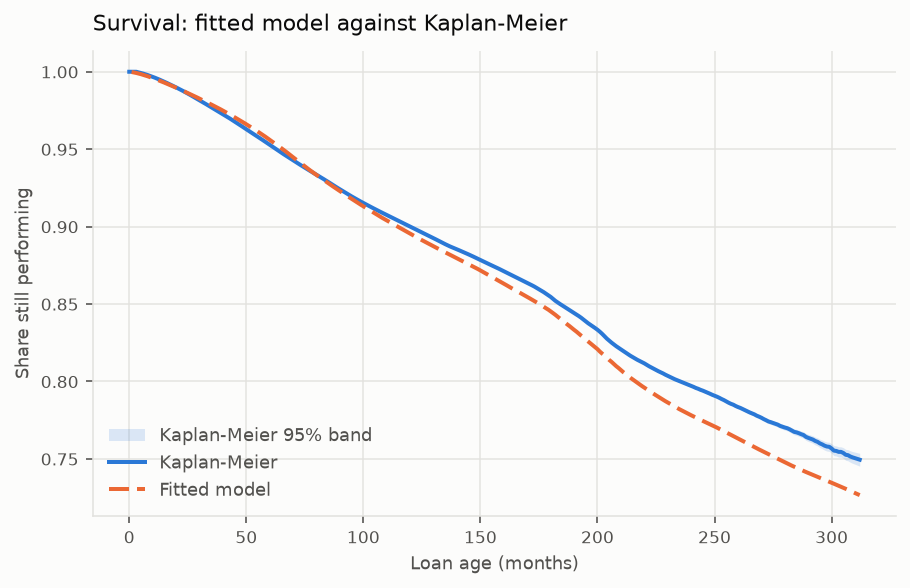

In [7]:
figure = Path(reports_dir()) / "figures" / "survival_vs_km.png"

if figure.exists():
    display(Image(str(figure)))
else:
    print(f"No figure at {figure}. Run: uv run creditsurv report")